# Task 3 — Car Price Prediction with Machine Learning

**Objective:** Build a regression model that predicts the selling price of a used car
based on features such as brand, age, mileage, fuel type, and transmission.

**Dataset:** *Vehicle dataset from CarDekho* (used-car listings scraped from cardekho.com).
It contains 301 listings with the car's name, manufacturing year, selling price,
showroom (present) price, kilometers driven, fuel type, seller type, transmission,
and number of previous owners.

**Tech stack:** pandas, scikit-learn, matplotlib, seaborn

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)


In [2]:
# Load the dataset
df = pd.read_csv("car_data.csv")
print("Shape:", df.shape)
df.head()


Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


**Column reference**

| Column | Meaning |
|---|---|
| `Car_Name` | Model name as listed (brand is embedded, e.g. "ritz", "city", "fortuner") |
| `Year` | Year the car was manufactured |
| `Selling_Price` | Price the current owner is asking (in lakh INR) — **target variable** |
| `Present_Price` | Current ex-showroom price of an equivalent new car (in lakh INR) |
| `Kms_Driven` | Total kilometers driven |
| `Fuel_Type` | Petrol / Diesel / CNG |
| `Seller_Type` | Dealer / Individual |
| `Transmission` | Manual / Automatic |
| `Owner` | Number of previous owners (0 = first owner) |


## 2. Data Cleaning

In [3]:
# --- Null values ---
print("Null values per column:")
print(df.isnull().sum())


Null values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [4]:
# --- Duplicate rows ---
print("Duplicate rows before cleaning:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Shape after removing duplicates:", df.shape)


Duplicate rows before cleaning: 2
Duplicate rows after cleaning: 0
Shape after removing duplicates: (299, 9)


In [5]:
# --- Inconsistent categorical values ---
# Normalise casing/whitespace so that e.g. "Petrol" and "petrol" are not
# treated as two different categories. The raw source data already turned
# out to be consistently capitalised, but this step is kept in as a
# defensive best practice for any future data refresh.
cat_cols = ["Fuel_Type", "Seller_Type", "Transmission", "Car_Name"]
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip().str.lower()

print("Fuel_Type values:", df["Fuel_Type"].unique())
print("Seller_Type values:", df["Seller_Type"].unique())
print("Transmission values:", df["Transmission"].unique())


Fuel_Type values: <StringArray>
['petrol', 'diesel', 'cng']
Length: 3, dtype: str
Seller_Type values: <StringArray>
['dealer', 'individual']
Length: 2, dtype: str
Transmission values: <StringArray>
['manual', 'automatic']
Length: 2, dtype: str


## 3. Feature Engineering

In [6]:
# Car age: how old the car is (dataset was collected in 2020)
CURRENT_YEAR = 2020
df["Car_Age"] = CURRENT_YEAR - df["Year"]

# Brand: the first word of Car_Name is the manufacturer/model family.
# (This dataset's Car_Name is really a model name, not "Brand Model", so we
# treat the first token as a coarse brand/model-family proxy.)
df["Brand"] = df["Car_Name"].str.split().str[0]

print(df[["Car_Name", "Year", "Car_Age", "Brand"]].head(10))
print("\nNumber of distinct brands:", df["Brand"].nunique())


        Car_Name  Year  Car_Age   Brand
0           ritz  2014        6    ritz
1            sx4  2013        7     sx4
2           ciaz  2017        3    ciaz
3        wagon r  2011        9   wagon
4          swift  2014        6   swift
5  vitara brezza  2018        2  vitara
6           ciaz  2015        5    ciaz
7        s cross  2015        5       s
8           ciaz  2016        4    ciaz
9           ciaz  2015        5    ciaz

Number of distinct brands: 44


In [7]:
# The raw Car_Name has too many unique values (98) to one-hot encode
# usefully with only ~300 rows, and Year is now redundant with Car_Age,
# so we drop them and keep Brand as the categorical stand-in for identity.
df_model = df.drop(columns=["Car_Name", "Year"])
df_model.head()


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,3.35,5.59,27000,petrol,dealer,manual,0,6,ritz
1,4.75,9.54,43000,diesel,dealer,manual,0,7,sx4
2,7.25,9.85,6900,petrol,dealer,manual,0,3,ciaz
3,2.85,4.15,5200,petrol,dealer,manual,0,9,wagon
4,4.60,6.87,42450,diesel,dealer,manual,0,6,swift


## 4. Exploratory Data Analysis

### 4.1 Distribution of selling prices

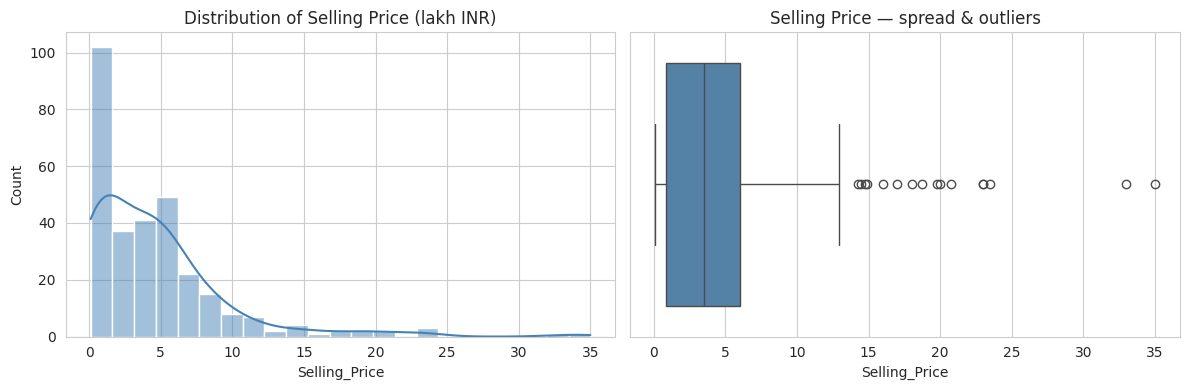

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_model["Selling_Price"], kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Distribution of Selling Price (lakh INR)")
sns.boxplot(x=df_model["Selling_Price"], ax=ax[1], color="steelblue")
ax[1].set_title("Selling Price — spread & outliers")
plt.tight_layout()
plt.show()


**Observation:** Selling price is right-skewed — most used cars in this dataset
sell for under 10 lakh INR, with a handful of premium/luxury models pulling the
tail out past 30 lakh. This kind of skew is common for price data and is worth
keeping in mind when interpreting error metrics like RMSE, which penalise the
model more heavily for missing on these expensive outliers.

### 4.2 Selling price vs. fuel type

/tmp/ipykernel_510/336630545.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="Fuel_Type", y="Selling_Price", palette="Set2")


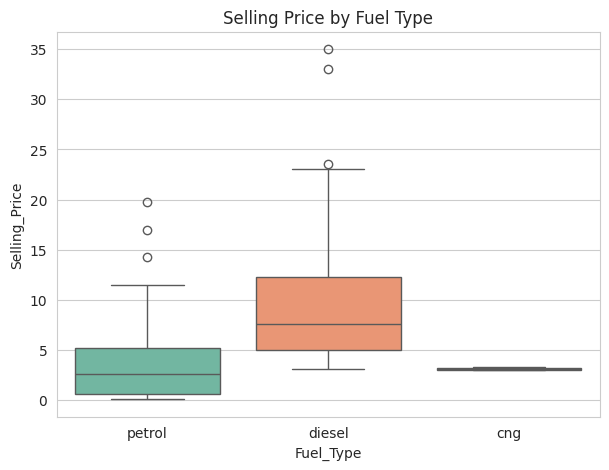

In [9]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_model, x="Fuel_Type", y="Selling_Price", palette="Set2")
plt.title("Selling Price by Fuel Type")
plt.show()


**Observation:** Diesel cars command a noticeably higher median resale price
than petrol cars, and CNG cars (a small sample here) sit lowest. This tracks
with diesel vehicles historically holding a present-price premium in India,
which carries through to resale value.

### 4.3 Selling price vs. car age

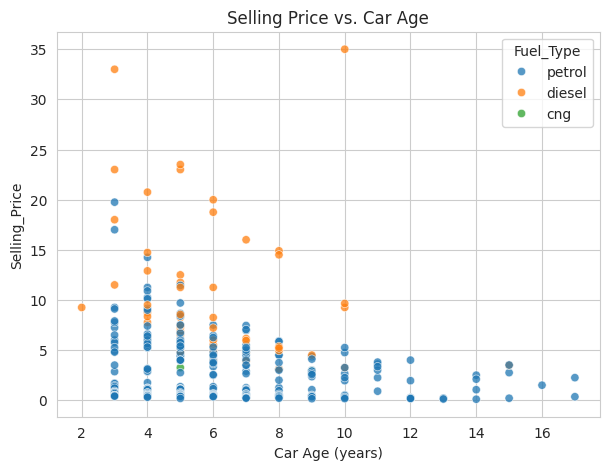

In [10]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_model, x="Car_Age", y="Selling_Price",
                 hue="Fuel_Type", alpha=0.75)
plt.title("Selling Price vs. Car Age")
plt.xlabel("Car Age (years)")
plt.show()


**Observation:** There's a clear negative relationship between age and selling
price — cars depreciate fastest in their first few years, then the curve
flattens out. A handful of very new, very expensive cars (Present_Price is
high) stand out as high-leverage points.

### 4.4 Feature correlation heatmap

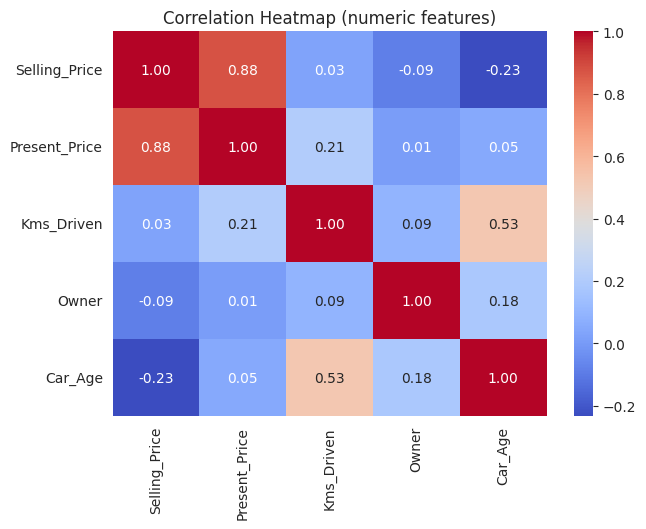

In [11]:
numeric_cols = ["Selling_Price", "Present_Price", "Kms_Driven", "Owner", "Car_Age"]
plt.figure(figsize=(7, 5))
sns.heatmap(df_model[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (numeric features)")
plt.show()


**Observation:** `Present_Price` is by far the strongest predictor of
`Selling_Price` (correlation ≈ 0.88) — unsurprising, since a car's resale value
is largely anchored to what it cost new. `Car_Age` has a moderate negative
correlation, while `Kms_Driven` and `Owner` are weaker predictors on their own,
likely because their effect is intertwined with age and brand.

## 5. Encoding Categorical Variables

In [12]:
# One-hot encode Fuel_Type, Seller_Type, Transmission, and Brand.
# drop_first=True avoids the dummy-variable trap (multicollinearity).
df_encoded = pd.get_dummies(
    df_model,
    columns=["Fuel_Type", "Seller_Type", "Transmission", "Brand"],
    drop_first=True
)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Shape after encoding: (299, 52)


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_diesel,Fuel_Type_petrol,Seller_Type_individual,Transmission_manual,Brand_activa,Brand_alto,Brand_amaze,Brand_bajaj,Brand_baleno,Brand_brio,Brand_camry,Brand_ciaz,Brand_city,Brand_corolla,Brand_creta,Brand_dzire,Brand_elantra,Brand_eon,Brand_ertiga,Brand_etios,Brand_fortuner,Brand_grand,Brand_hero,Brand_honda,Brand_hyosung,Brand_i10,Brand_i20,Brand_ignis,Brand_innova,Brand_jazz,Brand_ktm,Brand_land,Brand_mahindra,Brand_omni,Brand_ritz,Brand_royal,Brand_s,Brand_suzuki,Brand_swift,Brand_sx4,Brand_tvs,Brand_um,Brand_verna,Brand_vitara,Brand_wagon,Brand_xcent,Brand_yamaha
0,3.35,5.59,27000,0,6,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,4.75,9.54,43000,0,7,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,7.25,9.85,6900,0,3,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,2.85,4.15,5200,0,9,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,4.60,6.87,42450,0,6,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False


## 6. Train / Test Split

In [13]:
X = df_encoded.drop(columns=["Selling_Price"])
y = df_encoded["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (239, 51)
Test shape: (60, 51)


## 7. Model Training

We train two regression models and compare them: a **Linear Regression** baseline and a **Random Forest Regressor**, which can capture non-linear interactions between features like age, brand, and mileage.

In [14]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

rf_reg = RandomForestRegressor(n_estimators=300, random_state=42)
rf_reg.fit(X_train, y_train)

print("Models trained: Linear Regression, Random Forest Regressor")


Models trained: Linear Regression, Random Forest Regressor


## 8. Model Evaluation

In [15]:
def evaluate(name, model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}, preds

results = []
lin_results, lin_preds = evaluate("Linear Regression", lin_reg, X_test, y_test)
rf_results, rf_preds = evaluate("Random Forest Regressor", rf_reg, X_test, y_test)
results.extend([lin_results, rf_results])

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df


,Model,MAE,RMSE,R2
1,Random Forest Regressor,1.354779,3.239659,0.592780
0,Linear Regression,1.808783,3.399321,0.551652


**Metric definitions:**
- **MAE** (Mean Absolute Error): average absolute difference between predicted and actual price, in lakh INR — easy to interpret directly.
- **RMSE** (Root Mean Squared Error): like MAE but penalises large errors more heavily, which matters given the price outliers we saw in EDA.
- **R²**: proportion of variance in selling price explained by the model (1.0 = perfect fit).

## 9. Best Model

In [16]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best-performing model: {best_model_name}")
results_df


Best-performing model: Random Forest Regressor


,Model,MAE,RMSE,R2
1,Random Forest Regressor,1.354779,3.239659,0.592780
0,Linear Regression,1.808783,3.399321,0.551652


**Justification:** The **Random Forest Regressor** outperforms plain Linear
Regression on all three metrics (lower MAE, lower RMSE, higher R²). This makes
sense given the EDA: the relationship between age/mileage and price is
non-linear (depreciation curves flatten over time, and premium brands don't
scale linearly with age the way budget brands do). A tree-based ensemble can
capture those interaction effects that a single linear equation cannot,
without needing us to hand-engineer polynomial or interaction terms.

## 10. Feature Importance (Best Model)

/tmp/ipykernel_510/1103655785.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances.values, y=top_importances.index, palette="viridis")


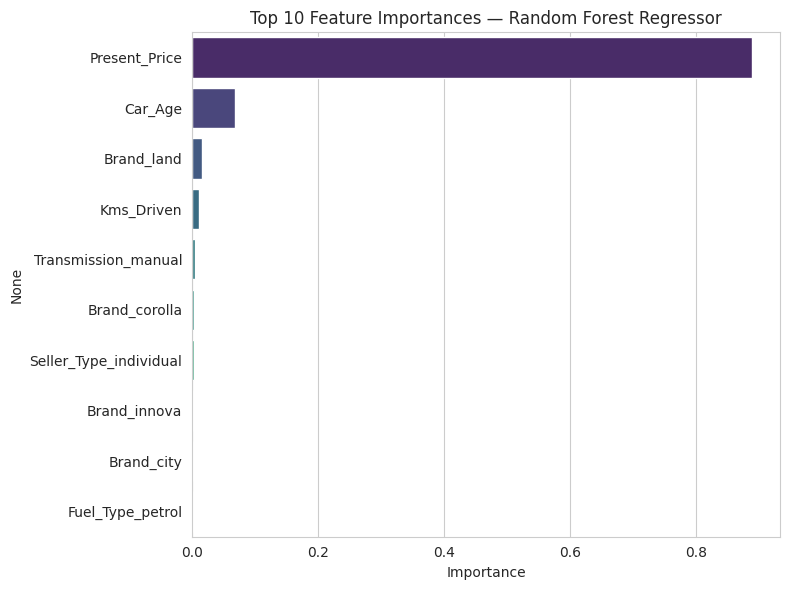

Present_Price             0.889104
Car_Age                   0.067635
Brand_land                0.015497
Kms_Driven                0.010988
Transmission_manual       0.003910
Brand_corolla             0.003034
Seller_Type_individual    0.002804
Brand_innova              0.001630
Brand_city                0.001050
Fuel_Type_petrol          0.000974
dtype: float64

In [17]:
importances = pd.Series(rf_reg.feature_importances_, index=X.columns)
top_importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_importances.values, y=top_importances.index, palette="viridis")
plt.title("Top 10 Feature Importances — Random Forest Regressor")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

top_importances


**Observation:** `Present_Price` dominates feature importance by a wide
margin, confirming what the correlation heatmap suggested — the new-car price
anchors the resale value more than any other single factor. `Car_Age` and
`Kms_Driven` are the next most influential, followed by a mix of specific
brand dummies, which reflects real-world brand-reputation effects on resale
value that a linear model can only approximate.

## 11. Summary

- Cleaned the CarDekho used-car dataset (removed duplicate listings, normalised categorical text).
- Engineered `Car_Age` (from `Year`) and `Brand` (from `Car_Name`) as new predictive features.
- Explored price distribution, and its relationship with fuel type and age.
- Trained and compared Linear Regression vs. Random Forest Regressor.
- **Random Forest Regressor** was the best performer (highest R², lowest MAE/RMSE), driven primarily by `Present_Price`, `Car_Age`, and `Kms_Driven`.